In [6]:
import pandas as pd
import numpy as np
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as sts
import warnings
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics.pairwise import cosine_similarity
import pickle
from sklearn.metrics.pairwise import linear_kernel

warnings.filterwarnings('ignore', category=FutureWarning)

In [7]:
df = pd.read_csv("/kaggle/input/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
df.shape

(8807, 12)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [10]:
df['show_id'].value_counts()

show_id
s8807    1
s1       1
s2       1
s3       1
s4       1
        ..
s12      1
s11      1
s10      1
s9       1
s8       1
Name: count, Length: 8807, dtype: int64

In [11]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [12]:
df['title'].value_counts()

title
Zubaan                                 1
Dick Johnson Is Dead                   1
Blood & Water                          1
Ganglands                              1
Jailbirds New Orleans                  1
                                      ..
Bangkok Breaking                       1
Vendetta: Truth, Lies and The Mafia    1
The Starling                           1
The Great British Baking Show          1
Sankofa                                1
Name: count, Length: 8807, dtype: int64

In [13]:
df['director'].value_counts()

director
Rajiv Chilaka              19
Raúl Campos, Jan Suter     18
Suhas Kadav                16
Marcus Raboy               16
Jay Karas                  14
                           ..
James Brown                 1
Ivona Juka                  1
Mu Chu                      1
Chandra Prakash Dwivedi     1
Majid Al Ansari             1
Name: count, Length: 4528, dtype: int64

In [14]:
df['cast'].value_counts()

cast
David Attenborough                                                                                                                                                      19
Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jigna Bhardwaj, Rajesh Kava, Mousam, Swapnil                                                                                 14
Samuel West                                                                                                                                                             10
Jeff Dunham                                                                                                                                                              7
Michela Luci, Jamie Watson, Eric Peterson, Anna Claire Bartlam, Nicolas Aqui, Cory Doran, Julie Lemieux, Derek McGrath                                                   6
                                                                                                                                            

In [15]:
df['country'].value_counts()

country
United States                                                      2818
India                                                               972
United Kingdom                                                      419
Japan                                                               245
South Korea                                                         199
                                                                   ... 
Mexico, United States, Spain, Colombia                                1
Canada, Norway                                                        1
Finland, Germany, Belgium                                             1
Argentina, United States, Mexico                                      1
United Kingdom, United States, Germany, Denmark, Belgium, Japan       1
Name: count, Length: 748, dtype: int64

In [16]:
df['date_added'].value_counts()

date_added
January 1, 2020       109
November 1, 2019       89
March 1, 2018          75
December 31, 2019      74
October 1, 2018        71
                     ... 
February 2, 2017        1
September 11, 2019      1
May 17, 2015            1
June 5, 2018            1
October 14, 2017        1
Name: count, Length: 1767, dtype: int64

In [17]:
df['release_year'].value_counts()

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
        ... 
1961       1
1925       1
1959       1
1966       1
1947       1
Name: count, Length: 74, dtype: int64

In [18]:
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [19]:
df['duration'].value_counts()

duration
1 Season     1793
2 Seasons     425
3 Seasons     199
90 min        152
97 min        146
             ... 
228 min         1
18 min          1
205 min         1
201 min         1
191 min         1
Name: count, Length: 220, dtype: int64

In [20]:
df['listed_in'].value_counts()

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
                                                   ... 
Action & Adventure, Cult Movies                       1
Action & Adventure, Comedies, Music & Musicals        1
Classic Movies, Horror Movies, Thrillers              1
Children & Family Movies, Classic Movies, Dramas      1
Cult Movies, Dramas, Thrillers                        1
Name: count, Length: 514, dtype: int64

In [21]:
df['description'].value_counts()

description
Paranormal activity at a lush, abandoned property alarms a group eager to redevelop the site, but the eerie events may not be as unearthly as they think.    4
A surly septuagenarian gets another chance at her 20s after having her photo snapped at a studio that magically takes 50 years off her life.                 3
Multiple women report their husbands as missing but when it appears they are looking for the same man, a police officer traces their cryptic connection.     3
Challenged to compose 100 songs before he can marry the girl he loves, a tortured but passionate singer-songwriter embarks on a poignant musical journey.    3
A scheming matriarch plots to cut off her disabled stepson and his wife from the family fortune, creating a division within the clan.                        2
                                                                                                                                                            ..
Decades after the assassination of

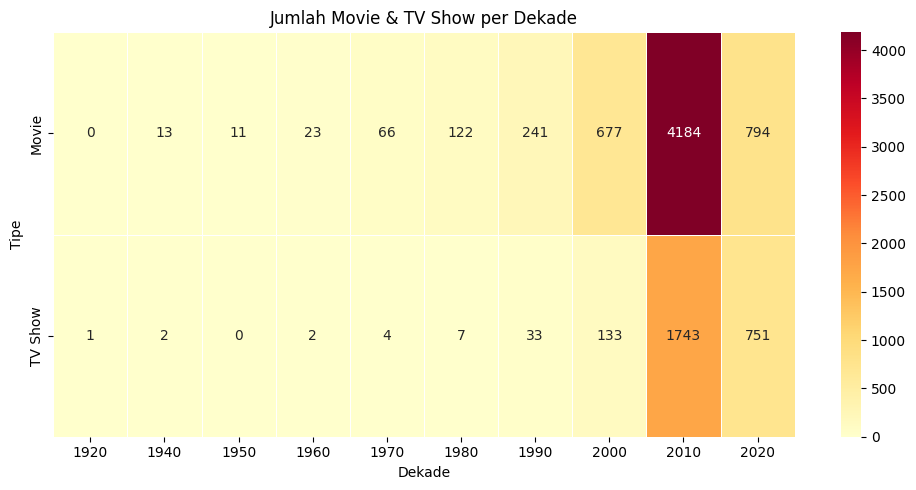

In [22]:
df['decade'] = (df['release_year'] // 10) * 10  # Kelompokkan ke dekade

decade_type = df.groupby(['decade', 'type']).size().unstack(fill_value=0)

# Visualisasikan heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(decade_type.T, cmap='YlOrRd', annot=True, fmt='d', linewidths=0.5)
plt.title('Jumlah Movie & TV Show per Dekade')
plt.xlabel('Dekade')
plt.ylabel('Tipe')
plt.tight_layout()
plt.show()



Text(0, 0.5, 'Genre')

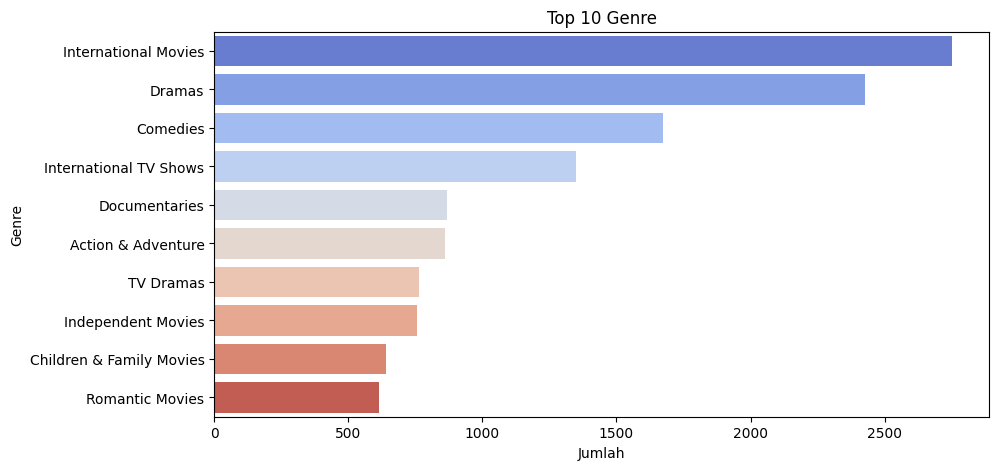

In [23]:
# 4. Top 10 Genre (listed_in)
plt.figure(figsize=(10, 5))
# Genre bisa lebih dari 1, jadi perlu explode
df_genre = df['listed_in'].dropna().str.split(', ').explode()
top_genre = df_genre.value_counts().nlargest(10)
sns.barplot(y=top_genre.index, x=top_genre.values, palette='coolwarm')
plt.title('Top 10 Genre')
plt.xlabel('Jumlah')
plt.ylabel('Genre')

Text(0, 0.5, 'Negara')

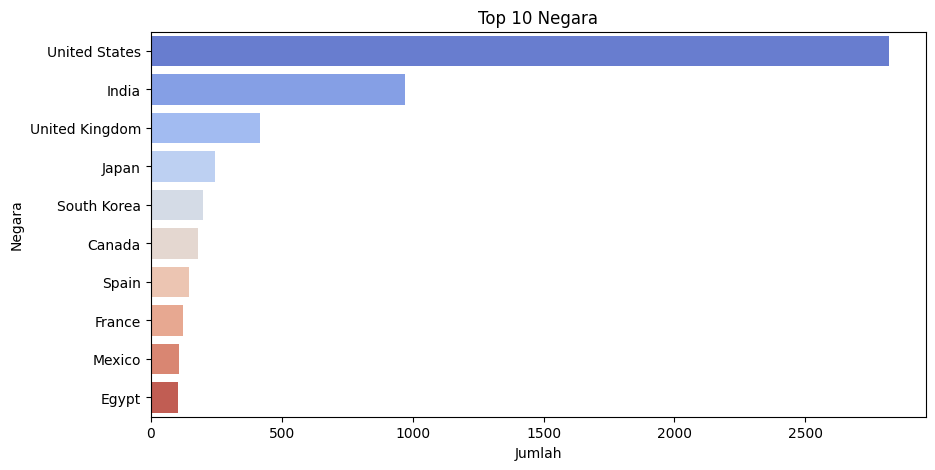

In [24]:
plt.figure(figsize=(10, 5))
top_countries = df['country'].value_counts().nlargest(10)
sns.barplot(y=top_countries.index, x=top_countries.values, palette='coolwarm')
plt.title('Top 10 Negara')
plt.xlabel('Jumlah')
plt.ylabel('Negara')

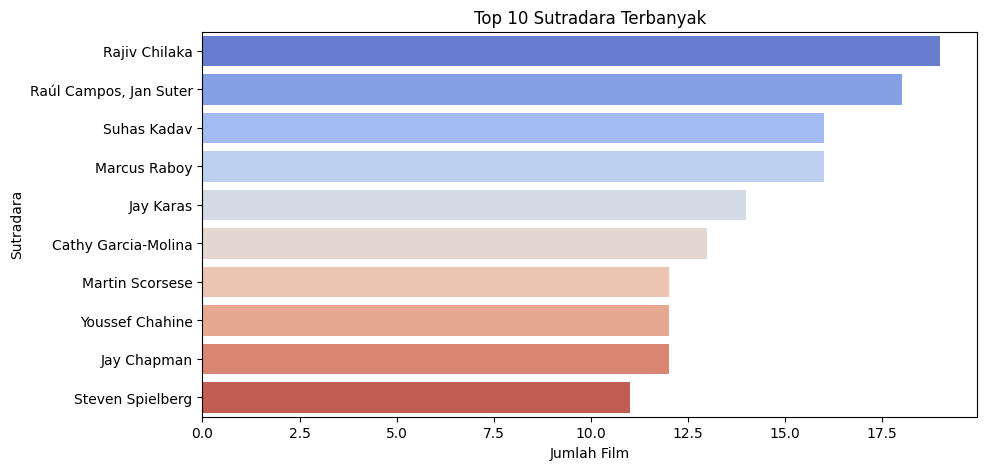

In [25]:
# top 10 director
plt.figure(figsize=(10, 5))
top_directors = df['director'].dropna().value_counts().nlargest(10)
sns.barplot(y=top_directors.index, x=top_directors.values, palette='coolwarm')
plt.title('Top 10 Sutradara Terbanyak')
plt.xlabel('Jumlah Film')
plt.ylabel('Sutradara')
plt.show()


In [26]:
# duplicate data in title
title_duplicates = df['title'].duplicated().sum()
print(f"Duplikat di Title: {title_duplicates}")

Duplikat di Title: 0


## Checking Null Value

In [27]:
miss_value = df.isnull().sum()
miss_value

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
decade             0
dtype: int64

## Prepocessing

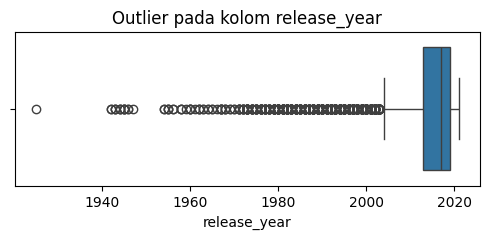

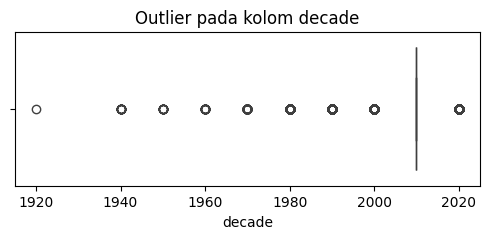

In [28]:
# show outlier
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Outlier pada kolom {col}')
    plt.show()

In [29]:
df['description'] = df['description'].fillna('')
df['cast'] = df['cast'].fillna('')
df['cast'] = df['cast'].apply(lambda x: [i.strip().lower().replace(' ', '') for i in x.split(',')[:3]]) 
df['genres'] = df['listed_in'].fillna('').apply(lambda x: [g.strip().lower().replace(' ', '') for g in x.split(',')])
df['director'] = df['director'].fillna('')
df['director'] = df['director'].apply(lambda x: [x.strip().lower().replace(' ', '')] if x else [])


In [30]:
def create_soup(x):
    return ' '.join(x['genres'] + x['cast'] + x['director']) + ' ' + x['type']

df['soup'] = df.apply(create_soup, axis=1)


In [31]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['soup'])

cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

In [32]:
indices = pd.Series(df.index, index=df['title']).drop_duplicates()
titles = df['title']

In [33]:
indices_lowercase = pd.Series(df.index, index=df['title'].str.lower())

In [34]:
def get_recommendations(title, topn=5):
    title_input = title.lower()
    
    if title_input not in indices_lowercase:
        return f"**{title}** tidak ditemukan "

    idx = indices_lowercase[title_input]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:topn+1]
    rec_idxs = [i[0] for i in sim_scores]
    
    return df[['title','type','release_year','description','genres']].iloc[rec_idxs]


In [38]:
print(get_recommendations('STRANGER THINGS', topn=5))

                               title     type  release_year  \
6953                           Helix  TV Show          2015   
2190            The Umbrella Academy  TV Show          2020   
2303                     Warrior Nun  TV Show          2020   
3187                     Nightflyers  TV Show          2018   
1473  Chilling Adventures of Sabrina  TV Show          2020   

                                            description  \
6953  While investigating a possible outbreak at an ...   
2190  Reunited by their father's death, estranged si...   
2303  After waking up in a morgue, an orphaned teen ...   
3187  With humankind's future at stake, a group of s...   
1473  Magic and mischief collide as half-human, half...   

                                                 genres  
6953          [tvhorror, tvmysteries, tvsci-fi&fantasy]  
2190  [tvaction&adventure, tvmysteries, tvsci-fi&fan...  
2303  [tvaction&adventure, tvmysteries, tvsci-fi&fan...  
3187          [tvhorror, tvmysteri

In [39]:
print(get_recommendations('stranger things', topn=5))

                               title     type  release_year  \
6953                           Helix  TV Show          2015   
2190            The Umbrella Academy  TV Show          2020   
2303                     Warrior Nun  TV Show          2020   
3187                     Nightflyers  TV Show          2018   
1473  Chilling Adventures of Sabrina  TV Show          2020   

                                            description  \
6953  While investigating a possible outbreak at an ...   
2190  Reunited by their father's death, estranged si...   
2303  After waking up in a morgue, an orphaned teen ...   
3187  With humankind's future at stake, a group of s...   
1473  Magic and mischief collide as half-human, half...   

                                                 genres  
6953          [tvhorror, tvmysteries, tvsci-fi&fantasy]  
2190  [tvaction&adventure, tvmysteries, tvsci-fi&fan...  
2303  [tvaction&adventure, tvmysteries, tvsci-fi&fan...  
3187          [tvhorror, tvmysteri

In [40]:
print(get_recommendations('Stranger Things', topn=5))

                               title     type  release_year  \
6953                           Helix  TV Show          2015   
2190            The Umbrella Academy  TV Show          2020   
2303                     Warrior Nun  TV Show          2020   
3187                     Nightflyers  TV Show          2018   
1473  Chilling Adventures of Sabrina  TV Show          2020   

                                            description  \
6953  While investigating a possible outbreak at an ...   
2190  Reunited by their father's death, estranged si...   
2303  After waking up in a morgue, an orphaned teen ...   
3187  With humankind's future at stake, a group of s...   
1473  Magic and mischief collide as half-human, half...   

                                                 genres  
6953          [tvhorror, tvmysteries, tvsci-fi&fantasy]  
2190  [tvaction&adventure, tvmysteries, tvsci-fi&fan...  
2303  [tvaction&adventure, tvmysteries, tvsci-fi&fan...  
3187          [tvhorror, tvmysteri

In [41]:
# Simpan dictionary ini. 
with open('netflix_df.pkl', 'wb') as f:
    pickle.dump(df, f)
